In [1]:
import math as m
import numpy as np
import astropy.units as u
import astropy.wcs.utils as utils
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.coordinates import SkyCoord
from scipy import constants
from scipy.ndimage import shift
from astropy.modeling import models, fitting
import scipy.stats as stats 
import warnings
from astropy.wcs import FITSFixedWarning
warnings.simplefilter('ignore', FITSFixedWarning)
import math
from astroquery.gaia import Gaia
Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source"
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from copy import deepcopy
from matplotlib.ticker import ScalarFormatter
from tqdm import tqdm

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


# **Start Values**

In [2]:
path_image_1 = "/home/wesley/Desktop/JWST_REU/2025_stage_2_data/"
path_image_2 = "/home/wesley/Desktop/JWST_REU/rob_2026_data/"

In [3]:
hdu_1_A = fits.open((path_image_1 + 'nan_rm_jwst_2025_f444w_f470n_d1_frame_A.fits'))[1]
hdu_1_B = fits.open((path_image_1 + 'nan_rm_jwst_2025_f444w_f470n_d1_frame_B.fits'))[1]

hdu_2_A = fits.open((path_image_2 + 'nan_rm_jwst_2026_f444w_f470n_d1_frame_A.fits'))[1]
hdu_2_B = fits.open((path_image_2 + 'nan_rm_jwst_2026_f444w_f470n_d1_frame_B.fits'))[1]

In [4]:
hdu_1_A.header['CRPIX1']

1024.5

In [5]:
hdu_1_A.header['CRPIX1'] += 9.283557398276237
hdu_1_A.header['CRPIX2'] += 0.8621134465311443

In [6]:
hdu_1_A.header['CRPIX1']

1033.7835573982763

In [7]:
# #define the image data
im_1_A = hdu_1_A.data
im_2_A = hdu_2_A.data
#defines the header
header_1_A = hdu_1_A.header
# header_2 = hdu_2.header
header_2_A = hdu_2_A.header

# #define the image data
im_1_B = hdu_1_B.data
im_2_B = hdu_2_B.data
#defines the header
header_1_B = hdu_1_B.header
# header_2 = hdu_2.header
header_2_B = hdu_2_B.header

In [8]:
#defines a cutout basied on the position of the protostar
cutout_size = (.06 * u.deg, .06 * u.deg)
# cutout_1 = Cutout2D(hdu_1.data/0.1382*10.4, center_protostar, cutout_size, wcs=WCS(hdu_1.header))
# cutout_2 = Cutout2D(hdu_2.data, center_protostar, cutout_size, wcs=WCS(hdu_2.header))
#define the distance to the protostar in parsecs here for converting into velocity later

#define the amount of time between the images in years. if you have more accray just implment that later in the code instead of this varable
time_pictures = 1
#error in the position measurements
# position_error = .5 * hdu_1_A.header['CDELT1'] * 3600*  distance_protostar

In [9]:
x_offset = - 9.283557398276237
y_offset  =-  0.8621134465311443

In [10]:
x_offset

-9.283557398276237

# **Standard Deviation**

0.58599424 0.603102 0.5944866


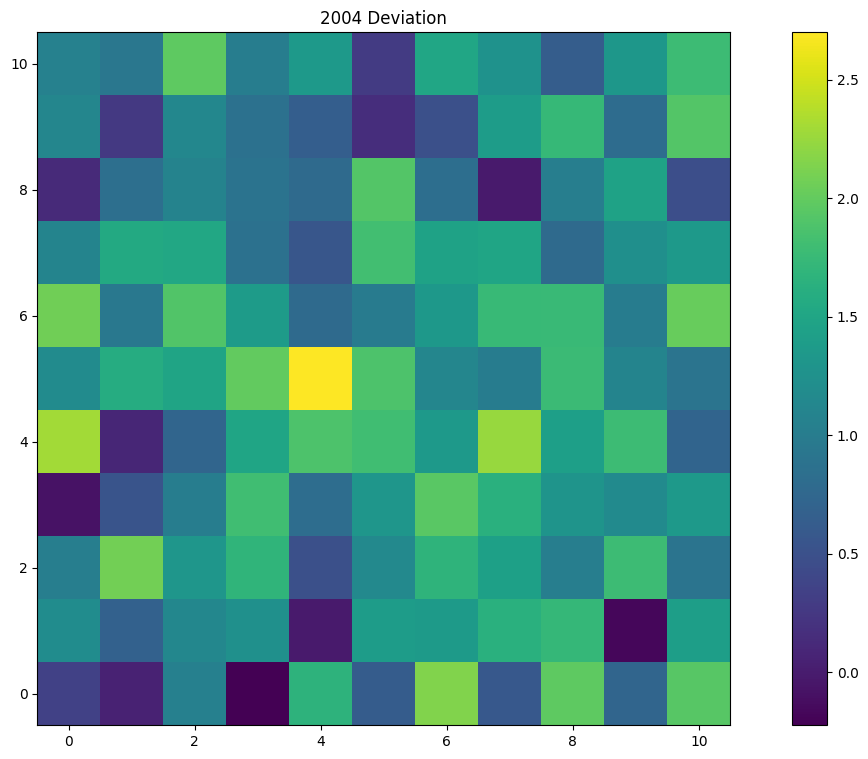

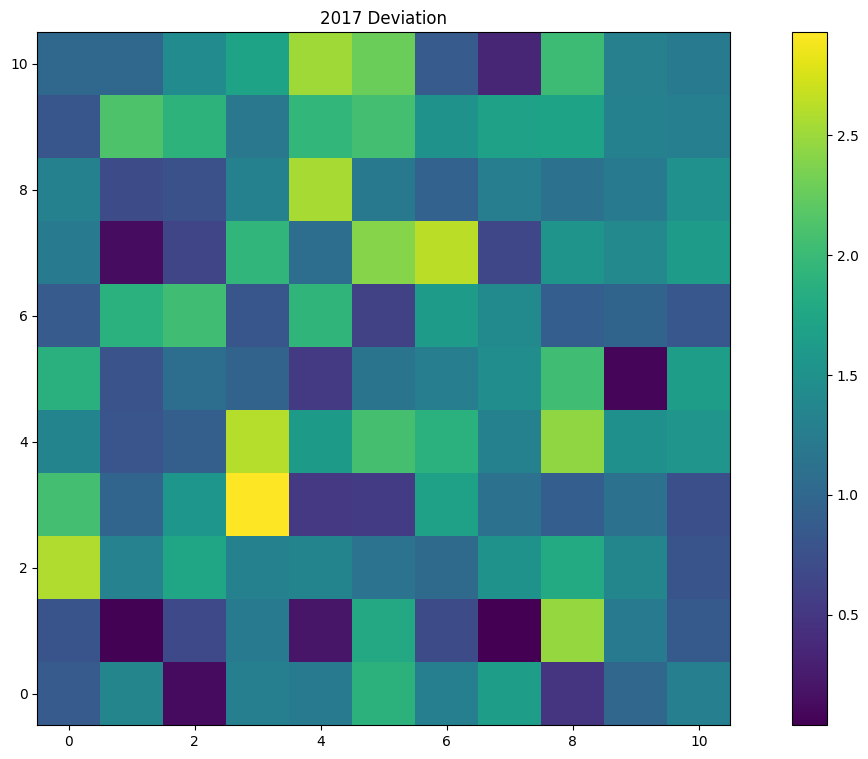

In [11]:
#define the x, y position of the knot
dev_x = [473, int(473 - x_offset)]
dev_y = [1240, int(1240 - y_offset)]
#define the size of the image
size_dev = [5, 5]
i=0
#creates the first image
std_04 = im_1_A[dev_y[i]-size_dev[i]:dev_y[i]+size_dev[i]+1, dev_x[i]-size_dev[i]:dev_x[i]+size_dev[i]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_04, vmin=np.min(std_04), vmax=np.max(std_04), origin="lower")
plt.colorbar()
title_1 = "2004 Deviation"
ax.set_title(title_1)
std_17 = im_2_A[dev_y[i+1]-size_dev[i+1]:dev_y[i+1]+size_dev[i+1]+1, dev_x[i+1]-size_dev[i+1]:dev_x[i+1]+size_dev[i+1]+1]
#this normalizes the data to elimnate the changes in brightness and reduces error
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
plt.imshow(std_17, vmin=np.min(std_17), vmax=np.max(std_17), origin="lower")
plt.colorbar()
title_2 = "2017 Deviation"
ax.set_title(title_2)
dev_04 = np.std(std_04)
dev_17 = np.std(std_17)
deviation = np.sqrt(dev_04*dev_17)
print (dev_04, dev_17, deviation)

# **"Chi Method"**

In [12]:
i = 0
#creates a list of incremental names for the knots ploted 
h = 0
# knot_name = [f"east_{h}" for h in range(1, 3)] + [f"west_{h}" for h in range(3, 0, -1)
# print (knot_name)

In [13]:
def chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction, bollian = True):
    if bollian:
        im_1 = im_1_A
        im_2 = im_2_A

        header_1 = hdu_1_A.header
        header_2 = hdu_2_A.header

        hdu_1 = hdu_1_A
        hdu_2 = hdu_2_A
        
    else:
        im_1 = im_1_B
        im_2 = im_2_B 

        header_1 = hdu_1_B.header
        header_2 = hdu_2_B.header

        hdu_1 = hdu_1_B
        hdu_2 = hdu_2_B

        
    #allows for the h varable to be acessed from within the definition
    global h, i
    #allows all plots to be made without warning
    plt.rcParams['figure.max_open_warning'] = 200
    #temporary arrays used for the process 
    pvalues = []
    chi_velocity = []
    chi_squ = []
    #sets the tital colors i use
    origin_color = 'green'
    lowest_color = 'red'
    two_color = 'blue'    
    # Define slice boundaries
    #i subtract 3 from the left and add four to the right
    #this ensures that when i shift the real data is conserved 
    #then after the shifting the added size is subtracted off
    #right side is larger due to the middle being defined as the 0,0 point with the size_chi being added to both sides
    ymin1 = cy_chi[i] - size_chi[i] - 3
    ymax1 = cy_chi[i] + size_chi[i] + 4
    xmin1 = cx_chi[i] - size_chi[i] - 3
    xmax1 = cx_chi[i] + size_chi[i] + 4
    #array_1 pulls image_1 from the defined size and center position
    #the median of that image in an area "median_factor" time bigger is then subtracted from the array
    array_1 = im_1[ymin1:ymax1, xmin1:xmax1] - np.median(
        im_1[
            cy_chi[i] - (median_factor * size_chi[i]) - 3 : cy_chi[i] + (median_factor * size_chi[i]) + 4,
            cx_chi[i] - (median_factor * size_chi[i]) - 3 : cx_chi[i] + (median_factor * size_chi[i]) + 4
        ]
    )
    #a zoomed in version of array_1 used for image displaying purposes
    zoom_sub1 = array_1[3:4 + (2 * size_chi[i]), 3:4 + (2 * size_chi[i])]
    #pulls wcs for displaying the croped image's coordnates correctly
    wcs_1 = deepcopy(WCS(hdu_1))
    wcs_1.wcs.crpix[0] -= xmin1 +3
    wcs_1.wcs.crpix[1] -= ymin1 +3
    #This does the same process for the second image
    # Define slice boundaries
    ymin2 = cy_chi[i+1] - size_chi[i+1] - 3
    ymax2 = cy_chi[i+1] + size_chi[i+1] + 4
    xmin2 = cx_chi[i+1] - size_chi[i+1] - 3
    xmax2 = cx_chi[i+1] + size_chi[i+1] + 4
    #array_2 pulls image_2
    array_2 = im_2[ymin2:ymax2, xmin2:xmax2] - np.median(
        im_2[
            cy_chi[i+1] - (median_factor * size_chi[i+1]) - 3 : cy_chi[i+1] + (median_factor * size_chi[i+1]) + 4,
            cx_chi[i+1] - (median_factor * size_chi[i+1]) - 3 : cx_chi[i+1] + (median_factor * size_chi[i+1]) + 4
        ]
    )
    #a zoomed in version of array_2
    zoom_sub2 = array_2[3:4 + (2 * size_chi[i]), 3:4 + (2 * size_chi[i])]
    #pulls wcs
    wcs_2 = deepcopy(WCS(hdu_2))
    wcs_2.wcs.crpix[0] -= xmin2 +3
    wcs_2.wcs.crpix[1] -= ymin2 +3
    #converts the pixel coordinates of the (0,0) coord of the defined shape into ra and dec
    left_1 = utils.pixel_to_skycoord((0.0+(cx_chi[i])-size_chi[i]), (0.0+(cy_chi[i])-size_chi[i]),WCS(header_1), origin=0, mode='all', cls=None)
    left_2 = utils.pixel_to_skycoord((0.0+(cx_chi[i+1])-size_chi[i+1]), (0.0+(cy_chi[i+1])-size_chi[i+1]), WCS(header_2), origin=0, mode='all', cls=None)
    #calculates the diffrences between the ra and dec between the two images
    left_dif_x = (left_1.ra.deg-left_2.ra.deg)
    left_dif_y = (left_1.dec.deg-left_2.dec.deg)
    #converts the diffrences in ra and dec into pixel amounts

    x_axis_scale = np.sqrt(header_2['CD1_1'] **2 + header_2['CD2_1'] **2 ) * 3600
    y_axis_scale = np.sqrt(header_2['CD1_2'] **2 + header_2['CD2_2'] **2 ) * 3600
    
    new_x = (left_dif_x /  x_axis_scale)
    new_y = (left_dif_y /  y_axis_scale)
    #defines the initial shift to be the diffrences in ra and dec
    initial = [new_y, new_x]
    #systematically runs through all values defined by the height and width and asigns them a diffrent shift amount that is incrmented by the "shift amount"
    #the hight and width says how many time the shift amount will be the max shift
    #it then appends all of the shift amounts to pvalues which is the shifts that are made
    for p in range(-width, width + 1, +1):
        for j in range(height, -height - 1, -1):
            pvalues.append([initial[0]+j*shift_amount, initial[1]+p*shift_amount])
    #this creates a deviation for the slice of the image
    ndev2 = (deviation / np.sum(array_2[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])]))**2  + .01/np.sum(array_2[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])])
    #creates a normalized array for the second image
    sub2 = (array_2[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])])/np.sum(array_2[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])])
    #runs through all shift amounts and shift the first image by every amount and then subtracts that from the second image
    for k, pv in enumerate(pvalues):
        #this shifts array_1 by the amount pv
        shift_array = (shift(array_1, pv, mode='nearest'))
        #this then cuts out the extra data
        zoom_shift = shift_array[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])]
        #normalizes the zoomed in array
        zoom_array_nrom = zoom_shift/np.sum(zoom_shift)
        #subtracts the normalized second image from the shifted normalized first image
        subtracted_array = sub2 - zoom_array_nrom
        #creates a "chi squared" value for every shift amount that is used to quantitatively analize each shift 
        squared = np.sum(np.square(subtracted_array)/ndev2) /   (((size_chi[i]*2+1)**2) - 2)
        chi_squ.append(squared)
    #defines the amount where in the array the chi squared value is the lowest
    min_value = np.argwhere(chi_squ == np.min(chi_squ))
    #defines the shift amount that gives the lowest chi value
    index = min_value[0, 0]    

    #converts the pixles shift of the lowest chi squared into kilometers per second
    delta_x = ((((pvalues[index][1]-initial[1])*x_axis_scale*distance_protostar*149597870.69)/(31536000*time_pictures)))
    delta_y = ((((pvalues[index][0]-initial[0])*y_axis_scale*distance_protostar*149597870.69)/(31536000*time_pictures)))
    #define the overall velocity using pythagorean theorem
    velocity = (np.sqrt((delta_x*delta_x)+(delta_y*delta_y)))
    #prints the important information for determining fit strength
    print ('minimum chi squared value = ', np.min(chi_squ), ',', 'X shift = ', pvalues[index][1]-initial[1], ',', 'Y shift = ', pvalues[index][0]-initial[0])
    print ('Vx', delta_x, 'Vy', delta_y)
    print ('velocity', velocity)
    #redefines the chi squared data into a 2d array with the correct dimentions  
    chi_squ_2d = np.array(chi_squ).reshape((2 * height + 1, 2 * width + 1))
    #makes blank grids that the velocity data is used for the axies of the chi sqared space
    x_grid = []
    y_grid = []
    for k, pv in enumerate(pvalues):
        x_grid.append(((pv[1]-initial[1])*x_axis_scale*distance_protostar*149597870.69)/(31536000*time_pictures))
        y_grid.append(((pv[0]-initial[0])*y_axis_scale*distance_protostar*149597870.69)/(31536000*time_pictures))
    #converts arrays into a numpy array because python
    x_grid = np.array(x_grid)
    y_grid = np.array(y_grid)
    #defines the boundries of a square confidence region that overestimates the actual uncertainty
    #if the "chi squared" value is less than two time the minimum value it is the area of error
    vx_left = np.min(x_grid[np.argwhere((chi_squ/(np.min(chi_squ)) <= 2))])
    vx_right = np.max(x_grid[np.argwhere((chi_squ/(np.min(chi_squ)) <= 2))])
    vy_bottom = np.min(y_grid[np.argwhere((chi_squ/(np.min(chi_squ)) <= 2))])
    vy_top = np.max(y_grid[np.argwhere((chi_squ/(np.min(chi_squ)) <= 2))])
    #creates the square using the dimensions above
    error_bar.append(np.sqrt((((delta_x)/velocity)**2) * ((vx_right-vx_left)/2)**2 + (((delta_y)/velocity)**2) * ((vy_top-vy_bottom)/2)**2))
    print ('V error ±', np.sqrt((((delta_x)/velocity)**2) * ((vx_right-vx_left)/2)**2 + (((delta_y)/velocity)**2) * ((vy_top-vy_bottom)/2)**2))
    print ('Vx error ±', ((vx_right-vx_left)/2), 'Vy error ±', ((vy_top-vy_bottom)/2))
    print ('angle =',((180*np.arctan2(-1*(pvalues[index][1]-initial[1]),(pvalues[index][0]-initial[0]))/np.pi)))
    print ('angle error ±',(180/np.pi)*np.sqrt(((((-1*(delta_y))/((delta_y)**2 + (delta_x)**2))**2)*((vx_right - vx_left) / 2)**2) +((((delta_x)/(delta_y**2 + delta_x**2))**2)*(((vy_top - vy_bottom) / 2))**2)))
    #reshapes the grid into the correct shape
    x_grid_2d = np.array(x_grid).reshape((2 * height + 1, 2 * width + 1))
    y_grid_2d = np.array(y_grid).reshape((2 * height + 1, 2 * width + 1))
    #image 1
    #places an arrow on the image from the brightest pixel in the first image
    #to the amount of shift that was measured 
    fig = plt.figure(figsize=(18, 5))
    ax1 = fig.add_subplot(1, 3, 1, projection=wcs_1)  # WCS projection
    ax2 = fig.add_subplot(1, 3, 2, projection=wcs_2)
    ax3 = fig.add_subplot(1, 3, 3, projection=wcs_2)
    for ax in [ax1, ax2, ax3]:
        ax.tick_params(axis='both', labelsize=8)
        ax.xaxis.label.set_fontsize(8)
        ax.yaxis.label.set_fontsize(8)
    plt.subplot(131)
    ax1.coords['ra'].set_axislabel('Right Ascension')
    ax1.coords['dec'].set_axislabel('Declination')
    im = ax1.imshow(zoom_sub1, vmin=np.min(zoom_sub1), vmax=np.max(zoom_sub1), origin="lower")
    cbar1 = plt.colorbar(im, ax=ax1)
    cbar1.ax.tick_params(labelsize=7)
    title_1 = "2004 Knot "
    ax1.set_title(title_1)  
    ax1.arrow(
        np.argmax(np.max(zoom_sub1, axis=0)),  # x start
        np.argmax(np.max(zoom_sub1, axis=1)),  # y start
        pvalues[index][1]-initial[1],  # dx
        pvalues[index][0]-initial[0],  # dy
        head_width=.1,
        head_length=.1,
        overhang=1,
        color='red',
        width=0.01
    )
    #finds the position of the brightest pixel in image 1 and converts it to wcs
    knot_1_bright = utils.pixel_to_skycoord(np.argmax(np.max(zoom_sub1, axis=0)),np.argmax(np.max(zoom_sub1, axis=1)), wcs_1, origin=0, mode='all', cls=None)
    #converts the wcs found to the pixel value in the second image
    knot_1_bright_pixels_2_wcs = utils.skycoord_to_pixel(knot_1_bright, WCS(hdu_2.header))
    knot_1_bright_pixels_in_zoom2 = utils.skycoord_to_pixel(knot_1_bright, wcs_2)

    #image 2
    plt.subplot(132)
    ax2.coords['ra'].set_axislabel('Right Ascension')
    ax2.coords['dec'].set_axislabel('Declination')
    im = ax2.imshow(zoom_sub2, vmin=np.min(zoom_sub2), vmax=np.max(zoom_sub2), origin="lower")
    cbar2 = plt.colorbar(im, ax=ax2)
    cbar2.ax.tick_params(labelsize=7)  
    ax2.set_title("2017 Knot")
    # ax2.arrow(
    #     knot_1_bright_pixels_2_wcs[0]-cx_chi[1]-size_chi[0],  # x start
    #     knot_1_bright_pixels_2_wcs[1]-cy_chi[1]-size_chi[0],  # y start
    #     ((pvalues[index][1])),  # dx
    #     ((pvalues[index][0])),  # dy
    #     head_width=1,
    #     head_length=1,
    #     overhang=1,
    #     color='red',
    #     width=0.01
    # )
    bx1 = np.argmax(np.max(zoom_sub1, axis=0))
    by1 = np.argmax(np.max(zoom_sub1, axis=1))

    # Position in im_1 full frame
    full_x1 = bx1 + 3 + xmin1
    full_y1 = by1 + 3 + ymin1

    # The center of image 1's cutout in im_1 is (cx_chi[i], cy_chi[i])
    # The center of image 2's cutout in im_2 is (cx_chi[i+1], cy_chi[i+1])
    # Offset of bright pixel from center in im_1:
    dx_from_center = full_x1 - cx_chi[i]
    dy_from_center = full_y1 - cy_chi[i]

    # Same offset applied in zoom_sub2 frame (center of zoom_sub2 is at size_chi[i])
    ax2_x = size_chi[i] + dx_from_center
    ax2_y = size_chi[i] + dy_from_center

    ax2.arrow(
        ax2_x,
        ax2_y,
        pvalues[index][1] - initial[1],
        pvalues[index][0] - initial[0],
        head_width=.1,
        head_length=.1,
        overhang=1,
        color='red',
        width=0.01
    )

    #shifts by the best amount for displaying
    best_fit_array = (shift(array_1, (pvalues[index][0],pvalues[index][1]), mode='nearest')[3:4+(2*size_chi[i]), 3:4+(2*size_chi[i])])
    #normalizes the best fit
    best_fit_array_norm = best_fit_array/np.sum(best_fit_array)
    #subtracts the best fit normalized second image from the best fit shifted normalized first image
    best_subtracted = (sub2 - best_fit_array_norm)
    #best image plot
    plt.subplot(133)
    im3 = ax3.imshow(best_subtracted, origin='lower', vmin=np.min(best_subtracted), vmax=np.max(best_subtracted), cmap='viridis')
    cbar3 = plt.colorbar(im3, ax=ax3)
    cbar3.ax.tick_params(labelsize=7)
    title_2_1 = "2017 Knot - 2004 Knot "
    ax3.set_title(title_2_1)  
    ax3.coords['ra'].set_axislabel('Right Ascension')
    ax3.coords['dec'].set_axislabel('Declination')
    #saves and shows the figure
    # plt.savefig(f"{save_path}{knot_name[h]}_knot.pdf", bbox_inches='tight')
    plt.show()  
    #plots a contour of the chi squared values on the velocity grid
    fig, ax = plt.subplots(1, 1, figsize=(16, 9))
    levels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12 ,13 ,14, 15, 16, 17,18, 19, 20]
    #plots the countour
    plt.contour(x_grid_2d, y_grid_2d, chi_squ_2d/np.min(chi_squ_2d), levels, origin='lower')
    plt.contour(x_grid_2d, y_grid_2d, chi_squ_2d/np.min(chi_squ_2d), [2], colors = 'red', origin='lower')
    plt.scatter(delta_x, delta_y,  marker='.', s=40, color='red',  label=f"Velocity (pre-correction): {velocity:.2f} km s$^{{-1}}$, Error: ± {(np.sqrt((((delta_x)/velocity)**2) * ((vx_right-vx_left)/2)**2 + (((delta_y)/velocity)**2) * ((vy_top-vy_bottom)/2)**2)):.2f} km s$^{{-1}}$")
    plt.colorbar()        
    plt.rc('font', size=10)
    plt.legend(loc='upper left')
    # plt.savefig(f"{save_path}{knot_name[h]}_knot_contour_plot.pdf", bbox_inches='tight')
    plt.show()
    #converts the position of the knots on the first image grid into sky coords
    knot_position_1 = knot_1_bright
    knot_position_2 = utils.pixel_to_skycoord(
        (cx_chi[0] - size_chi[0] + np.argmax(np.max(zoom_sub1, axis=0)) + (pvalues[index][1]-initial[1])),
        (cy_chi[0] - size_chi[0] + np.argmax(np.max(zoom_sub1, axis=1)) + (pvalues[index][0]-initial[0])),
        WCS(header_1), origin=0, mode='all', cls=None)   
    x_coord_1_chi.append((cx_chi[0] + np.argmax(np.max(zoom_sub1, axis=0)))-size_chi[0])
    y_coord_1_chi.append((cy_chi[0] + np.argmax(np.max(zoom_sub1, axis=1)))-size_chi[0])
    x_coord_2_chi.append(((cx_chi[0] + (np.argmax(np.max(zoom_sub1, axis=0))-size_chi[0]))+(pvalues[index][1]-initial[1])))
    y_coord_2_chi.append((cy_chi[0] + (np.argmax(np.max(zoom_sub1, axis=1))-size_chi[0]))+(pvalues[index][0]-initial[0]))
    knot_separation_protostar = (knot_position_1.separation(center_protostar)) 
    knot_separation_1_2 = (knot_position_1.separation(knot_position_2))
    knot_knot_sep.append(knot_separation_1_2)
    position_storage.append((knot_separation_protostar*3600*distance_protostar*direction).value)
    velocity_storage_x.append(delta_x) 
    velocity_storage_y.append(delta_y)
    knot_angle.append((180*np.arctan2((-1*(pvalues[index][1]-initial[1])),(pvalues[index][0]-initial[0]))/np.pi))
    chi_value.append(np.min(chi_squ))
    angle_error.append((180/np.pi)*np.sqrt(((((-1*(delta_y))/((delta_y)**2 + (delta_x)**2))**2)*((vx_right - vx_left) / 2)**2) +((((delta_x)/(delta_y**2 + delta_x**2))**2)*(((vy_top - vy_bottom) / 2))**2)))
    x_error.append((vx_right-vx_left)/2)
    y_error.append((vy_top-vy_bottom)/2)
    h += 1

# **HOPS 93?**

In [14]:
#define the position of the protostar in degrees
RA_Protostar = 15 * (5. + (35./60) + 15.048/3600)
DEC_Protostar = -1 * (5. + 0./60 + 8.05/3600)   
center_protostar = SkyCoord(ra = RA_Protostar, dec = DEC_Protostar, unit = 'deg')
distance_protostar = 392.7

In [15]:
#this is where the data is stored for processing graphs at the end of calculating all of the knots
position_storage = []
velocity_storage_x = []
velocity_storage_y = []
x_error = []
y_error = []
error_bar = []
x_coord_1_chi = []
y_coord_1_chi = []
x_coord_2_chi = []
y_coord_2_chi = []
knot_knot_sep = []
# gaia_x_hdu1 = []
# gaia_y_hdu1 = []
# gaia_x_hdu2 = []
# gaia_y_hdu2 = []
# gaia_Δx = []
# gaia_Δy = []
# delta_gaia_x = []
# delta_gaia_y = []
knot_angle = []
angle_error = [] 
chi_value = []

In [16]:
# plt.rcParams['figure.max_open_warning'] = 200
# #define the x, y position of the knot
# cx_chi = [1365, 1373]
# cy_chi = [129, 131]
# #define the size of the image
# size_chi = [15, 15]
# #how much bigger the median subtraction is from the image size
# median_factor = 2
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .1
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 150
# height = 150
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [17]:
position_storage_HOPS_93 = position_storage
velocity_storage_x_HOPS_93 = velocity_storage_x
velocity_storage_y_HOPS_93 = velocity_storage_y
x_error_HOPS_93 = x_error
y_error_HOPS_93 = y_error
error_bar_HOPS_93 = error_bar
x_coord_1_chi_HOPS_93 = x_coord_1_chi
y_coord_1_chi_HOPS_93 = y_coord_1_chi
x_coord_2_chi_HOPS_93 = x_coord_2_chi
y_coord_2_chi_HOPS_93 = y_coord_2_chi
knot_knot_sep_HOPS_93 = knot_knot_sep
# gaia_x_hdu1_HOPS_93 = gaia_x_hdu1
# gaia_y_hdu1_HOPS_93 = gaia_y_hdu1
# gaia_x_hdu2_HOPS_93 = gaia_x_hdu2
# gaia_y_hdu2_HOPS_93 = gaia_y_hdu2
# gaia_Δx_HOPS_93 = gaia_Δx
# gaia_Δy_HOPS_93 = gaia_Δy
# delta_gaia_x_HOPS_93 = delta_gaia_x
# delta_gaia_y_HOPS_93 = delta_gaia_y
knot_angle_HOPS_93 = knot_angle
angle_error_HOPS_93 = angle_error
chi_value_HOPS_93 = chi_value

# **HOPS 92?**

In [18]:
#define the position of the protostar in degrees
RA_Protostar = 15 * (5. + (35./60) + 18.337/3600)
DEC_Protostar = -1 * (5. + 0./60 + 32.94/3600)   
center_protostar = SkyCoord(ra = RA_Protostar, dec = DEC_Protostar, unit = 'deg')
distance_protostar = 392.7

In [19]:
#this is where the data is stored for processing graphs at the end of calculating all of the knots
position_storage = []
velocity_storage_x = []
velocity_storage_y = []
x_error = []
y_error = []
error_bar = []
x_coord_1_chi = []
y_coord_1_chi = []
x_coord_2_chi = []
y_coord_2_chi = []
knot_knot_sep = []
# gaia_x_hdu1 = []
# gaia_y_hdu1 = []
# gaia_x_hdu2 = []
# gaia_y_hdu2 = []
# gaia_Δx = []
# gaia_Δy = []
# delta_gaia_x = []
# delta_gaia_y = []
knot_angle = []
angle_error = [] 
chi_value = []

In [23]:
# # this is really weird?

# #define the x, y position of the knot
# cx_chi = [1656, 1667]
# cy_chi = [1830, 1831]
# #define the size of the image
# size_chi = [4, 4]
# #how much bigger the median subtraction is from the image size
# median_factor = 5
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 100
# height = 100
# direction = -1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

minimum chi squared value =  0.11501959 , X shift =  0.4 , Y shift =  0.05
Vx 46.7810657055389 Vy 5.876332052728226
velocity 47.14869443515768
V error ± 11.696160175150009
Vx error ± 11.69526642638472 Vy error ± 11.752664105456452
angle = -82.87498365109819
angle error ± 14.280927553269088


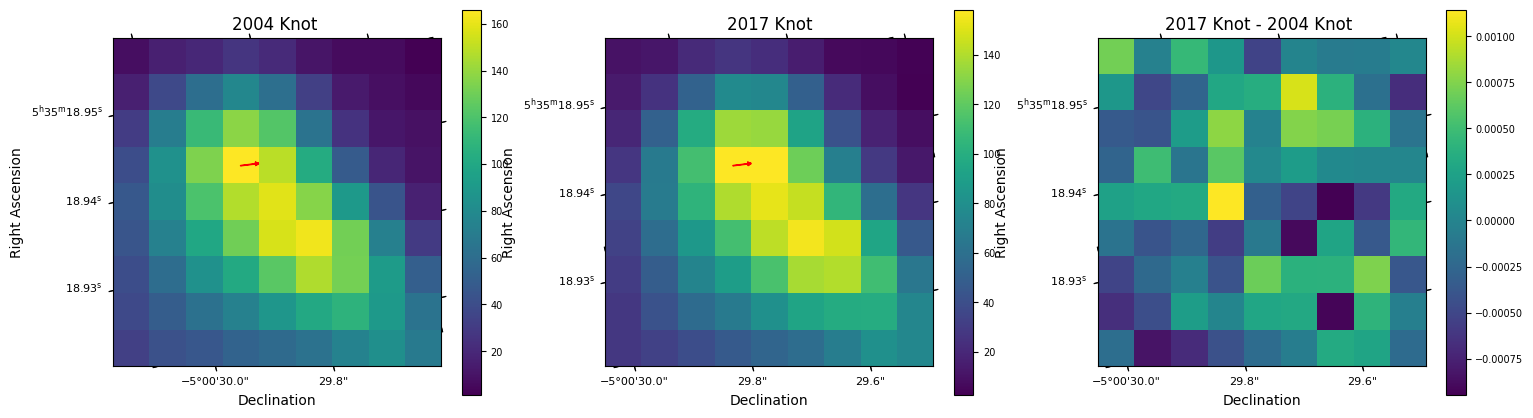

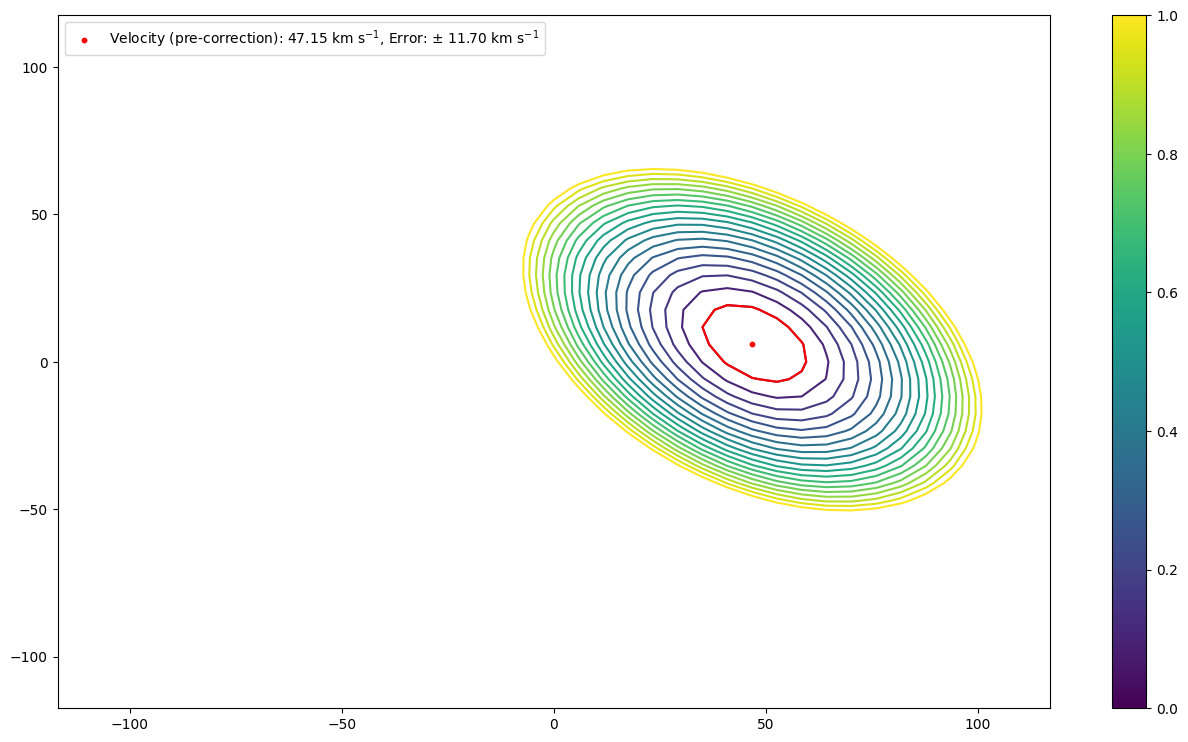

In [21]:
#define the x, y position of the knot
cx_chi = [1656, 1665]
cy_chi = [1830, 1831]
#define the size of the image
size_chi = [4, 4]
#how much bigger the median subtraction is from the image size
median_factor = 5
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 20
height = 20
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
# #define the x, y position of the knot
# cx_chi = [1640, 1650]
# cy_chi = [1800, 1802]
# #define the size of the image
# size_chi = [4, 4]
# #how much bigger the median subtraction is from the image size
# median_factor = 5
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 30
# height = 30
# direction = -1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
#define the x, y position of the knot
cx_chi = [1640, 1649]
cy_chi = [1801, 1802]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 5
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 30
height = 30
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
# #define the x, y position of the knot
# cx_chi = [1629, 1639]
# cy_chi = [1786, 1787]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 5
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 30
# height = 30
# direction = -1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
#define the x, y position of the knot
cx_chi = [1630, 1639]
cy_chi = [1786, 1787]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 5
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 30
height = 30
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
# #define the x, y position of the knot
# cx_chi = [1598, 1608]
# cy_chi = [1586, 1587]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 5
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 30
# height = 30
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
#define the x, y position of the knot
cx_chi = [1599, 1608]
cy_chi = [1586, 1587]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 5
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 30
height = 30
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
# #define the x, y position of the knot
# cx_chi = [1598, 1607]
# cy_chi = [1556, 1556]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 5
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
#define the x, y position of the knot
cx_chi = [1598, 1607]
cy_chi = [1556, 1557]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 5
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
# #define the x, y position of the knot
# cx_chi = [1601, 1610]
# cy_chi = [1507, 1507]
# #define the size of the image
# size_chi = [3, 3]
# #how much bigger the median subtraction is from the image size
# median_factor = 5
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
# #define the x, y position of the knot
# cx_chi = [1600, 1610]
# cy_chi = [1507, 1507]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 5
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
#define the x, y position of the knot
cx_chi = [1601, 1610]
cy_chi = [1506, 1507]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 5
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
# #define the x, y position of the knot
# cx_chi = [1600, 1610]
# cy_chi = [1461, 1462]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 5
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 50
# height = 50
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
#define the x, y position of the knot
cx_chi = [1601, 1610]
cy_chi = [1461, 1462]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 5
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 50
height = 50
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
# #define the x, y position of the knot
# cx_chi = [1586, 1596]
# cy_chi = [1397, 1398]
# #define the size of the image
# size_chi = [4, 4]
# #how much bigger the median subtraction is from the image size
# median_factor = 5
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 50
# height = 50
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
#define the x, y position of the knot
cx_chi = [1587, 1596]
cy_chi = [1397, 1398]
#define the size of the image
size_chi = [4, 4]
#how much bigger the median subtraction is from the image size
median_factor = 5
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 50
height = 50
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
# #define the x, y position of the knot
# cx_chi = [1633, 1643]
# cy_chi = [1206, 1205]
# #define the size of the image
# size_chi = [4, 4]
# #how much bigger the median subtraction is from the image size
# median_factor = 5
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 50
# height = 50
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
#define the x, y position of the knot
cx_chi = [1633, 1642]
cy_chi = [1205, 1206]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 5
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 50
height = 50
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
# #define the x, y position of the knot
# cx_chi = [1873, 1884]
# cy_chi = [612, 613]
# #define the size of the image
# size_chi = [6, 6]
# #how much bigger the median subtraction is from the image size
# median_factor = 5
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 50
# height = 50
# direction = 1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
#define the x, y position of the knot
cx_chi = [1875, 1884]
cy_chi = [612, 613]
#define the size of the image
size_chi = [6, 6]
#how much bigger the median subtraction is from the image size
median_factor = 5
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 50
height = 50
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
position_storage_HOPS_92 = position_storage
velocity_storage_x_HOPS_92 = velocity_storage_x
velocity_storage_y_HOPS_92 = velocity_storage_y
x_error_HOPS_92 = x_error
y_error_HOPS_92 = y_error
error_bar_HOPS_92 = error_bar
x_coord_1_chi_HOPS_92 = x_coord_1_chi
y_coord_1_chi_HOPS_92 = y_coord_1_chi
x_coord_2_chi_HOPS_92 = x_coord_2_chi
y_coord_2_chi_HOPS_92 = y_coord_2_chi
knot_knot_sep_HOPS_92 = knot_knot_sep
# gaia_x_hdu1_HOPS_93 = gaia_x_hdu1
# gaia_y_hdu1_HOPS_93 = gaia_y_hdu1
# gaia_x_hdu2_HOPS_93 = gaia_x_hdu2
# gaia_y_hdu2_HOPS_93 = gaia_y_hdu2
# gaia_Δx_HOPS_93 = gaia_Δx
# gaia_Δy_HOPS_93 = gaia_Δy
# delta_gaia_x_HOPS_93 = delta_gaia_x
# delta_gaia_y_HOPS_93 = delta_gaia_y
knot_angle_HOPS_92 = knot_angle
angle_error_HOPS_92 = angle_error
chi_value_HOPS_92 = chi_value

# **HOPS 88?**

In [ ]:
#define the position of the protostar in degrees
RA_Protostar = 15 * (5. + (35./60) + 22.471/3600)
DEC_Protostar = -1 * (5. + 1./60 + 14.31/3600)   
center_protostar = SkyCoord(ra = RA_Protostar, dec = DEC_Protostar, unit = 'deg')
distance_protostar = 392.7

In [ ]:
#this is where the data is stored for processing graphs at the end of calculating all of the knots
position_storage = []
velocity_storage_x = []
velocity_storage_y = []
x_error = []
y_error = []
error_bar = []
x_coord_1_chi = []
y_coord_1_chi = []
x_coord_2_chi = []
y_coord_2_chi = []
knot_knot_sep = []
# gaia_x_hdu1 = []
# gaia_y_hdu1 = []
# gaia_x_hdu2 = []
# gaia_y_hdu2 = []
# gaia_Δx = []
# gaia_Δy = []
# delta_gaia_x = []
# delta_gaia_y = []
knot_angle = []
angle_error = [] 
chi_value = []

In [ ]:
# #define the x, y position of the knot
# cx_chi = [864, 874]
# cy_chi = [2014, 2015]
# #define the size of the image
# size_chi = [2, 2]
# #how much bigger the median subtraction is from the image size
# median_factor = 5
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 20
# height = 20
# direction = -1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
#define the x, y position of the knot
cx_chi = [865, 874]
cy_chi = [2014, 2015]
#define the size of the image
size_chi = [2, 2]
#how much bigger the median subtraction is from the image size
median_factor = 5
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 20
height = 20
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
# #define the x, y position of the knot
# cx_chi = [878, 889]
# cy_chi = [1919, 1920]
# #define the size of the image
# size_chi = [10, 10]
# #how much bigger the median subtraction is from the image size
# median_factor = 5
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 20
# height = 20
# direction = -1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
#define the x, y position of the knot
cx_chi = [880, 889]
cy_chi = [1919, 1920]
#define the size of the image
size_chi = [10, 10]
#how much bigger the median subtraction is from the image size
median_factor = 5
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 20
height = 20
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
# #define the x, y position of the knot
# cx_chi = [862, 872]
# cy_chi = [1899, 1900]
# #define the size of the image
# size_chi = [5, 5]
# #how much bigger the median subtraction is from the image size
# median_factor = 5
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 40
# height = 40
# direction = -1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
#define the x, y position of the knot
cx_chi = [863, 872]
cy_chi = [1899, 1900]
#define the size of the image
size_chi = [5, 5]
#how much bigger the median subtraction is from the image size
median_factor = 5
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 40
height = 40
direction = -1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
position_storage_HOPS_88 = position_storage
velocity_storage_x_HOPS_88 = velocity_storage_x
velocity_storage_y_HOPS_88 = velocity_storage_y
x_error_HOPS_88 = x_error
y_error_HOPS_88 = y_error
error_bar_HOPS_88 = error_bar
x_coord_1_chi_HOPS_88 = x_coord_1_chi
y_coord_1_chi_HOPS_88 = y_coord_1_chi
x_coord_2_chi_HOPS_88 = x_coord_2_chi
y_coord_2_chi_HOPS_88 = y_coord_2_chi
knot_knot_sep_HOPS_88 = knot_knot_sep
# gaia_x_hdu1_HOPS_93 = gaia_x_hdu1
# gaia_y_hdu1_HOPS_93 = gaia_y_hdu1
# gaia_x_hdu2_HOPS_93 = gaia_x_hdu2
# gaia_y_hdu2_HOPS_93 = gaia_y_hdu2
# gaia_Δx_HOPS_93 = gaia_Δx
# gaia_Δy_HOPS_93 = gaia_Δy
# delta_gaia_x_HOPS_93 = delta_gaia_x
# delta_gaia_y_HOPS_93 = delta_gaia_y
knot_angle_HOPS_88 = knot_angle
angle_error_HOPS_88 = angle_error
chi_value_HOPS_88 = chi_value

# **HOPS 91?**

In [ ]:
#define the position of the protostar in degrees
RA_Protostar = 15 * (5. + (35./60) + 18.925/3600)
DEC_Protostar = -1 * (5. + 0./60 + 51.11/3600)   
center_protostar = SkyCoord(ra = RA_Protostar, dec = DEC_Protostar, unit = 'deg')
distance_protostar = 392.8

In [ ]:
#this is where the data is stored for processing graphs at the end of calculating all of the knots
position_storage = []
velocity_storage_x = []
velocity_storage_y = []
x_error = []
y_error = []
error_bar = []
x_coord_1_chi = []
y_coord_1_chi = []
x_coord_2_chi = []
y_coord_2_chi = []
knot_knot_sep = []
# gaia_x_hdu1 = []
# gaia_y_hdu1 = []
# gaia_x_hdu2 = []
# gaia_y_hdu2 = []
# gaia_Δx = []
# gaia_Δy = []
# delta_gaia_x = []
# delta_gaia_y = []
knot_angle = []
angle_error = [] 
chi_value = []

In [ ]:
# #define the x, y position of the knot
# cx_chi = [1073, 1082]
# cy_chi = [1663, 1664]
# #define the size of the image
# size_chi = [10, 10]
# #how much bigger the median subtraction is from the image size
# median_factor = 5
# #sets how much each chi is offset by. should be kept small to increase how accurate it is 
# shift_amount = .05
# #sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
# width = 20
# height = 20
# direction = -1
# chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
#define the x, y position of the knot
cx_chi = [1072, 1082]
cy_chi = [1663, 1664]
#define the size of the image
size_chi = [10, 10]
#how much bigger the median subtraction is from the image size
median_factor = 5
#sets how much each chi is offset by. should be kept small to increase how accurate it is 
shift_amount = .05
#sets many images wide the chi space will be. it is two times the width by two times the height and must be a square 
width = 50
height = 50
direction = 1
chi_system(cx_chi,cy_chi,size_chi,median_factor,shift_amount,width,height,direction)

In [ ]:
position_storage_HOPS_91 = position_storage
velocity_storage_x_HOPS_91 = velocity_storage_x
velocity_storage_y_HOPS_91 = velocity_storage_y
x_error_HOPS_91 = x_error
y_error_HOPS_91 = y_error
error_bar_HOPS_91 = error_bar
x_coord_1_chi_HOPS_91 = x_coord_1_chi
y_coord_1_chi_HOPS_91 = y_coord_1_chi
x_coord_2_chi_HOPS_91 = x_coord_2_chi
y_coord_2_chi_HOPS_91 = y_coord_2_chi
knot_knot_sep_HOPS_91 = knot_knot_sep
# gaia_x_hdu1_HOPS_93 = gaia_x_hdu1
# gaia_y_hdu1_HOPS_93 = gaia_y_hdu1
# gaia_x_hdu2_HOPS_93 = gaia_x_hdu2
# gaia_y_hdu2_HOPS_93 = gaia_y_hdu2
# gaia_Δx_HOPS_93 = gaia_Δx
# gaia_Δy_HOPS_93 = gaia_Δy
# delta_gaia_x_HOPS_93 = delta_gaia_x
# delta_gaia_y_HOPS_93 = delta_gaia_y
knot_angle_HOPS_91 = knot_angle
angle_error_HOPS_91 = angle_error
chi_value_HOPS_91 = chi_value

# **Graphs**

In [ ]:
#updates the velocities based on the systematic error found 
new_velocity_storage_x = ((np.abs(velocity_storage_x)) - ((np.mean(second_iteration_x)*distance_protostar*149597870.69)/(31536000*time_pictures)))
new_velocity_storage_y = ((np.abs(velocity_storage_y)) - ((np.mean(second_iteration_y)*distance_protostar*149597870.69)/(31536000*time_pictures)))
new_velocity_storage = (np.sqrt(new_velocity_storage_x **2 + new_velocity_storage_y **2))

In [ ]:
#creates image of full outflows
fig, ax = plt.subplots(1, 1, figsize=(16, 9), subplot_kw={'projection': WCS(hdu_1)})
ax.imshow(im_1.data-np.median(im_1.data), origin='lower',vmin=0, vmax=300, cmap='viridis', interpolation='none')
zoom = 100
H310_04_t = utils.skycoord_to_pixel(center_protostar, WCS(hdu_1.header))
H310_04 = np.array(H310_04_t)
H310_04_x = (np.array(H310_04_t[0]))
H310_04_y = (np.array(H310_04_t[1]))
ax.set_xlim([H310_04_x-zoom, H310_04_x+zoom])
ax.set_ylim([H310_04_y-zoom, H310_04_y+zoom])
plt.xticks([])
plt.yticks([])
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.coords['ra'].set_axislabel('Right Ascension')
plt.rc('font', size=10)
ax.coords['dec'].set_axislabel('Declination')
ax.scatter(H310_04_x, H310_04_y, s=100, marker='+', color='red', label='HOPS 354')
pacsec_pixels = (.125*206264.80624538/(distance_protostar*3600*header_1['CD1_1']))
dash_len = 5
y0 = 1390
x0 = 960
y1 = y0 + pacsec_pixels
for y in [y0, (y1)]:
    ax.hlines(y, x0 - dash_len, x0 + dash_len, color="#FFFFFF", linewidth=3.5)
ax.plot([x0, x0],[y0, (y1)],color="#FFFFFF", linewidth=3.5, label='0.125 parsecs')
# print(H310_04_x+zoom)

scaling_factor = 20.

for k in range(len(x_coord_1_chi)):
    ax.arrow(
        x_coord_1_chi[k], 
        1400,
        0, 
        -50, 
        head_width=6, 
        head_length=6,
        overhang=1,
        color='red', 
        width=0.03 * scaling_factor
    )
ax.arrow(
    x_coord_1_chi[1], 
    1400,
    0, 
    -50, 
    head_width=6, 
    head_length=6,
    overhang=1,
    color='red', 
    width=0.03 * scaling_factor,
    label='Used in chi squared'
)
ax.arrow(
    893,
    1400,
    0,
    -50,
    head_width=6, 
    head_length=6,
    overhang=1,
    color="#00B8E6", 
    width=0.03 * scaling_factor,
    label='Not Used'
)
ax.arrow(
    883,
    1400,
    0,
    -50,
    head_width=6, 
    head_length=6,
    overhang=1,
    color="#00B8E6", 
    width=0.03 * scaling_factor,
)
ax.arrow(
    873,
    1400,
    0,
    -50,
    head_width=6, 
    head_length=6,
    overhang=1,
    color="#00B8E6", 
    width=0.03 * scaling_factor,
)
ax.arrow(
    836,
    1400,
    0,
    -50,
    head_width=6, 
    head_length=6,
    overhang=1,
    color="#00B8E6", 
    width=0.03 * scaling_factor,
)
plt.legend(loc="upper left",fontsize=9)
plt.savefig(save_path + 'full_outflows.pdf', bbox_inches='tight', pad_inches=0)

In [ ]:
#creates image of full outflows with both images subracted 
fig, ax = plt.subplots(1, 1, figsize=(16, 9), subplot_kw={'projection': WCS(hdu_2)})
ax.imshow(hdu_2.data-(hdu_3.data), origin='lower', vmin=-20, vmax=30, cmap='viridis', interpolation='none')
zoom = 100
H310_04_t = utils.skycoord_to_pixel(center_protostar, WCS(hdu_1.header))
H310_04 = np.array(H310_04_t)
H310_17_t = utils.skycoord_to_pixel(center_protostar, WCS(hdu_2.header))
H310_04_x = (np.array(H310_04_t[0]))
H310_04_y = (np.array(H310_04_t[1]))
ax.set_xlim([H310_04_x-zoom, H310_04_x+zoom])
ax.set_ylim([H310_04_y-zoom, H310_04_y+zoom])
plt.xticks([])
plt.yticks([])
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.coords['ra'].set_axislabel('Right Ascension')
plt.rc('font', size=10)
ax.coords['dec'].set_axislabel('Declination')
plt.savefig(save_path + 'full_subtraction.pdf', bbox_inches='tight', pad_inches=0)

In [ ]:
#creates a plot showing the relationship between velocity and separation
#creates the plot
fig, ax = plt.subplots()
#sets the size of the graph
ax.set_xlim([-30000/10000, 30000/10000])
# ax.set_ylim([0, 350])
#places a point at 0,0 as refrence for the protostar
# ax.scatter(0, 0, marker='x', s=80, color='black', label='HOPS 310')
ax.axvline(x=0, color='k', label='No Separation')
for h in range(len(position_storage)):
    
    #plots the ne knot's distance from the protostar on the x axis and the velocity on the y axis
    ax.scatter((position_storage[h]/10000), (new_velocity_storage[h]), marker='+', s=80, color='red')
    #plots an error bar for the ne values based on the offset data 
    ax.errorbar(position_storage[h]/10000, new_velocity_storage[h], yerr=error_bar[h], color='red')   
#repeats 2 points for the sake of creating a legend that doesnt repeat
#displays the legend
ax.axhline(y=0, color='k')
plt.legend(loc="upper left")
#calls the axis lables and title
plt.rc('font', size=10)
ax.set_xlabel('Separation (10,000 au)')
ax.set_ylabel('Velocity (km s$^{-1}$)')
ax.set_title('Velocity vs Separation')
plt.savefig(save_path + 'full_velocity_vs_separation.pdf', bbox_inches='tight')
print ()

In [ ]:
## creates velocity arrows image
#cretes a plot
fig, ax = plt.subplots(1, 1, figsize=(16, 9), subplot_kw={'projection': WCS(hdu_1)})
#shows the cutout the 2004 image
ax.imshow(im_1.data-np.median(im_1.data), vmin=0, vmax=100, cmap='viridis', interpolation='none')
zoom = 100
#this plots the base of the sw knots and then uses an arrow to point to the position of the second arrow while also increasing the magnitude for visual clarity
scaling_factor = 5.0  # Increase this factor to make arrows longer
#this find the ratio between pixels and velocity in km s-1
factor = (new_velocity_storage[2])/(np.sqrt((x_coord_2_chi[2] - x_coord_1_chi[2])**2+(y_coord_2_chi[2] - y_coord_1_chi[2])**2))
#finds the pixel shift for a velocity of 200 km s-1; used for the scale bar
v_200 = 200/factor
for k in range(len(x_coord_1_chi)):
    dx = (x_coord_2_chi[k] - x_coord_1_chi[k]) * scaling_factor
    dy = (y_coord_2_chi[k] - y_coord_1_chi[k]) * scaling_factor
    ax.arrow(
        x_coord_1_chi[k], 
        y_coord_1_chi[k], 
        dx, 
        dy, 
        head_width=(scaling_factor), 
        head_length=(scaling_factor),
        overhang=1,
        color='red', 
        width=0.03 * scaling_factor
    )
dash_len = 2
for y in [1300, (1300 + v_200 * scaling_factor) + scaling_factor]:
    ax.hlines(y, 805 - dash_len, 805 + dash_len, color='#32CD32', linewidth=2)
ax.plot([805, 805],[1300, (1300 + v_200 * scaling_factor)+scaling_factor],color='#32CD32', linewidth=2, label='200 km s$^{-1}$')
ax.scatter(x_coord_1_chi, y_coord_1_chi, s=5, color='red')
ax.scatter(H310_04_x, H310_04_y, s=50, marker='+', color='red', label='HOPS 354')
H310_04_t = utils.skycoord_to_pixel(center_protostar, WCS(hdu_1.header))
H310_04 = np.array(H310_04_t)
H310_17_t = utils.skycoord_to_pixel(center_protostar, WCS(hdu_2.header))
H310_04_x = (np.array(H310_04_t[0]))
H310_04_y = (np.array(H310_04_t[1]))
ax.set_xlim([H310_04_x-zoom, H310_04_x+zoom])
ax.set_ylim([H310_04_y-zoom, H310_04_y+zoom])
plt.xticks([])
plt.yticks([])
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.rc('font', size=10)
ax.coords['ra'].set_axislabel('Right Ascension')
ax.coords['dec'].set_axislabel('Declination')
ax.legend(loc="upper left", handleheight=1*10**-99999)

plt.savefig(save_path + 'full_arrows.pdf', bbox_inches='tight', pad_inches=0)

In [ ]:
#shows realtionship between projected ejection time and distance from protostar
skycoord_1_chi =  utils.pixel_to_skycoord(x_coord_1_chi, y_coord_1_chi, WCS(header_1), origin=0, mode='all', cls=None)
skycoord_2_chi =  utils.pixel_to_skycoord(x_coord_2_chi, y_coord_2_chi, WCS(header_1), origin=0, mode='all', cls=None)

delta_separation = ((skycoord_2_chi.separation(skycoord_1_chi)).arcsecond)
arcsecond_position_2 = ((skycoord_2_chi.separation(center_protostar)).arcsecond)
arcsecond_position_1 = ((skycoord_1_chi.separation(center_protostar)).arcsecond)

dynamical_time = ((arcsecond_position_2/(arcsecond_position_2-arcsecond_position_1))*13)


dynamical_time_error = (dynamical_time*(error_bar/np.abs(new_velocity_storage)))

position_storage = np.array(position_storage)

dynamical_time_mask = (np.abs(dynamical_time_error) <  1e3)
# dynamical_time_mask = (np.abs(dynamical_time_error) <  1e999)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.scatter(np.abs(position_storage[dynamical_time_mask])/10000, dynamical_time[dynamical_time_mask], marker='_', s=80, color='blue',  label='Southwest')
ax.errorbar(np.abs(position_storage[dynamical_time_mask])/10000, dynamical_time[dynamical_time_mask], yerr=np.abs(dynamical_time_error[dynamical_time_mask]), color='blue', fmt='none')

ax.scatter((position_storage[dynamical_time_mask])/10000, dynamical_time[dynamical_time_mask], marker='_', s=80, color='red', label='Northeast')
ax.errorbar((position_storage[dynamical_time_mask])/10000, dynamical_time[dynamical_time_mask], yerr=np.abs(dynamical_time_error[dynamical_time_mask]), color='red', fmt='none')

# new_velocity_storage
# Weighted_arithmetic_mean = ((np.sum((np.abs(new_velocity_storage[dynamical_time_mask])) / ((dynamical_time_error[dynamical_time_mask])**2))) / np.sum(1/((dynamical_time_error[dynamical_time_mask])**2)))
# print ("m =",Weighted_arithmetic_mean)
# average_velocity = np.average(new_velocity_storage)
# inverse_velocity = 1/average_velocity

# xlength = np.linspace(0, 6, 20000)
# line_fit = average_velocity * xlength
# print (dynamical_time)
# print (line_fit)
# # plt.plot(xlength, line_fit, color='green', label=f'Line: {Weighted_arithmetic_mean:.5f} years per 10,000 au')
# plt.plot(xlength, line_fit, color='green', label=f'Line: {average_velocity:.5f} years per 10,000 au')


ax.legend()
ax.set_xlim(0, 60000/10000)
ax.set_ylim(0,3000)
plt.rc('font', size=10)

ax.set_xlabel('Separation (10,000 au)')
ax.set_ylabel('Time (Years)')
ax.set_title('Dynamical Time vs Separation')

plt.savefig(save_path + 'dynamical_time_vs_separation.pdf', bbox_inches='tight')

# print ('here',dynamical_time[dynamical_time_mask])
# print (dynamical_time_error[dynamical_time_mask])
# print (dynamical_time[dynamical_time_mask])
plt.show()

In [ ]:
#normalizes how angles are displayed
NW_angle = []
SE_angle = []
for d in range(len(knot_angle)): 
    if knot_angle[d] < 0:
        knot_angle[d] += 360
# np.where(knot_angle < 0, knot_angle+360,knot_angle)

for c in range (len(x_coord_1_chi)):
    proto_angle = (((180*np.arctan2(-1*(x_coord_1_chi[c] - H310_04_t[0]),(y_coord_1_chi[c] - H310_04_t[1]),)/np.pi)))
    if (proto_angle>0):
        SE_angle.append(float(proto_angle))
    else:
        NW_angle.append(float(proto_angle+360))
print (NW_angle)

In [ ]:
#creates a plot showing the relationship between angle and separation
#creates the plot
fig, ax = plt.subplots()
#sets the size of the graph
ax.set_xlim([-35000/10000, 35000/10000])
# ax.set_ylim([0, 360])
#places a point at 0,0 as refrence for the protostar
# ax.scatter(0, 0, marker='x', s=80, color='black', label='HOPS 310')
print (knot_angle)
ax.scatter(position_storage/10000, (knot_angle), marker='+', s=80, color='red')
ax.errorbar(position_storage/10000, (knot_angle), yerr=angle_error, color='red', fmt='none')
ax.axhline(y=(np.mean(NW_angle)), color='green', label='Average Angle')
ax.axhline(y=(np.mean(SE_angle)), color='green')
plt.rc('font', size=10)
ax.axvline(x=0, color='k', label='Protostar')
ax.set_xlabel('Separation (10,000 au)')
ax.set_ylabel('Angle (Deg.)')
ax.set_title('Angle vs Separation')
ax.legend()
plt.savefig(save_path + 'angle_vs_separation.pdf', bbox_inches='tight')
print ()

In [ ]:
#creates a plot showing the relationship between minimum "chi squared" value and separation
#creates the plot
fig, ax = plt.subplots()
#sets the size of the graph
# ax.set_xlim([-35000, 35000])
ax.set_ylim([0, 1.5])
#places a point at 0,0 as refrence for the protostar
# ax.scatter(0, 0, marker='x', s=80, color='black', label='HOPS 310')
ax.axvline(x=0, color='k', label='No Separation')
ax.scatter((position_storage), (chi_value), marker='+', s=80, color='red')
#displays the legend
plt.legend(loc="upper left")
#calls the axis lables and title
plt.rc('font', size=10)
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2)) 
ax.xaxis.set_major_formatter(formatter)
ax.set_xlabel('Separation (au)')
ax.set_ylabel(r'$\chi^2$')
ax.set_title(r'$\chi^2$ vs Separation')
plt.savefig(save_path + 'chi_value_vs_separation.pdf', bbox_inches='tight')
print ()

# **Done**

In [ ]:
print (np.average(new_velocity_storage))

In [ ]:
# print (z)
Ra_Dec = utils.pixel_to_skycoord(x_coord_1_chi, y_coord_1_chi, WCS(header_1), origin=0, mode='all', cls=None)
# knot_name[z], 
for z in range (len(knot_name)):
    print(position_storage[z])